In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
dog_rating_df = pd.read_csv('dog_rates_tweets.csv', parse_dates=['created_at'])

In [3]:
dog_rating_df['ratings'] = dog_rating_df['text'].str.extract(r'(\d+(\.\d+)?)/10')[0]

In [4]:
dog_rating_df = dog_rating_df.dropna(subset=['ratings'])
dog_rating_df['int_ratings'] = pd.to_numeric(dog_rating_df['ratings'], errors='coerce') # Source: https://stackoverflow.com/questions/31790287/convert-pandas-dataframe-column-from-string-to-int-based-on-conditional

In [5]:
dog_rating_df = dog_rating_df[dog_rating_df['int_ratings'] <= 25]

Text(0, 0.5, 'Ratings')

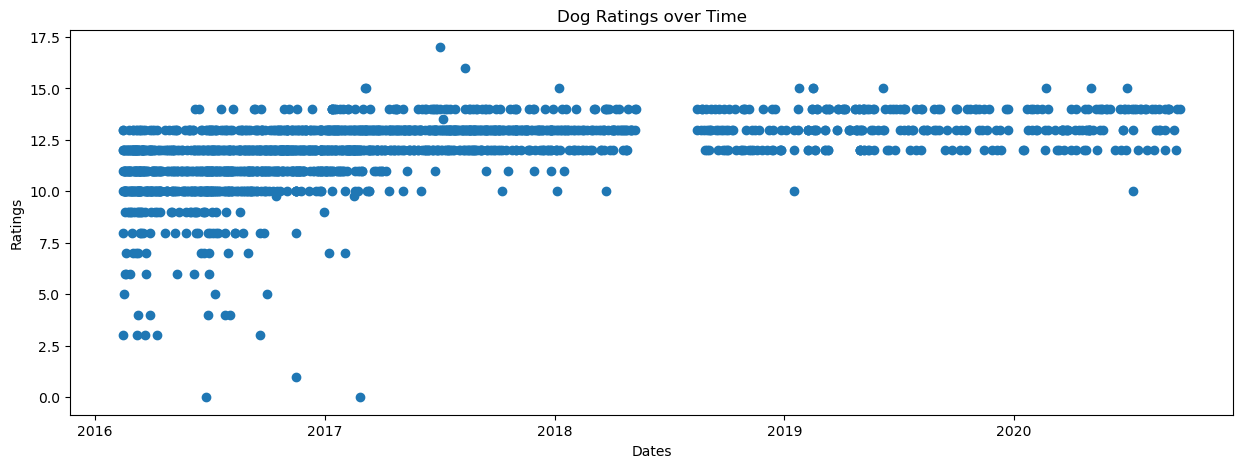

In [6]:
plt.figure(figsize=(15, 5))
plt.scatter(dog_rating_df['created_at'], dog_rating_df['int_ratings'])
plt.title('Dog Ratings over Time')
plt.xlabel('Dates')
plt.ylabel('Ratings')

In [7]:
def to_timestamp(dt):
    return dt.timestamp()

In [8]:
dog_rating_df['timestamp'] = dog_rating_df['created_at'].apply(to_timestamp)

In [9]:
best_fit_line = stats.linregress(dog_rating_df['timestamp'], dog_rating_df['int_ratings'])
dog_rating_df['prediction'] = dog_rating_df['timestamp']*best_fit_line.slope + best_fit_line.intercept
print(best_fit_line.pvalue)
print(best_fit_line.slope)
print(best_fit_line.intercept)

3.7937987731067315e-121
2.298303175224457e-08
-22.445058882763476


(array([  3.,   1.,   9.,   7.,  20.,  92., 708., 907., 122.,   2.]),
 array([-11.75256231, -10.07803188,  -8.40350145,  -6.72897102,
         -5.05444059,  -3.37991016,  -1.70537974,  -0.03084931,
          1.64368112,   3.31821155,   4.99274198]),
 <BarContainer object of 10 artists>)

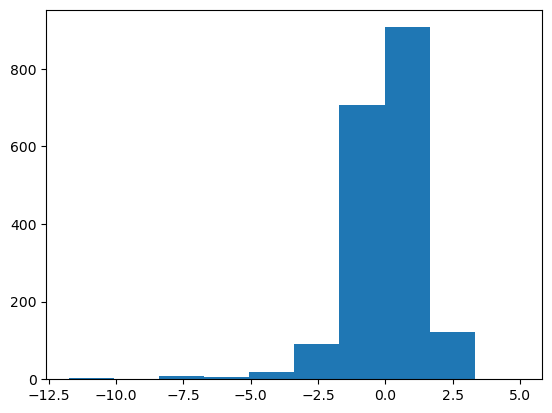

In [10]:
residuals = dog_rating_df['int_ratings'] - (best_fit_line.slope*dog_rating_df['timestamp'] + best_fit_line.intercept)
plt.hist(residuals)

In [11]:
dog_rating_df

,id,created_at,text,ratings,int_ratings,timestamp,prediction
2,994363623421153280,2018-05-09 23:48:56,This is Louie. He has misplaced his Cheerio. W...,14,14.0,1.525910e+09,12.624973
7,993889039714578432,2018-05-08 16:23:07,This is Manny. He hasn’t seen your croissant. ...,13,13.0,1.525797e+09,12.622373
8,993629544463642624,2018-05-07 23:11:58,This is Libby. She leap. 14/10\n(IG: libbythef...,14,14.0,1.525735e+09,12.620951
24,992198572664860672,2018-05-04 00:25:48,This is Rosie. She thought Coachella was this ...,13,13.0,1.525394e+09,12.613109
30,991744041351090177,2018-05-02 18:19:39,This is Riley. He’ll be your chauffeur this ev...,13,13.0,1.525285e+09,12.610619
...,...,...,...,...,...,...,...
11631,1096203765189726208,2019-02-15 00:25:18,"honorary 15/10 for Oppy, the very good space r...",15,15.0,1.550190e+09,13.183014
11638,1095730341828915200,2019-02-13 17:04:05,This is George. He doesn’t chew socks. He just...,14,14.0,1.550077e+09,13.180420
11665,1093636946046242817,2019-02-07 22:25:41,@Panthers @Proud_KCS 13/10 easy,13,13.0,1.549578e+09,13.168949
11666,1093636812818472960,2019-02-07 22:25:09,RT @GeekandSundry: .@Dog_Rates Announces a New...,13,13.0,1.549578e+09,13.168949


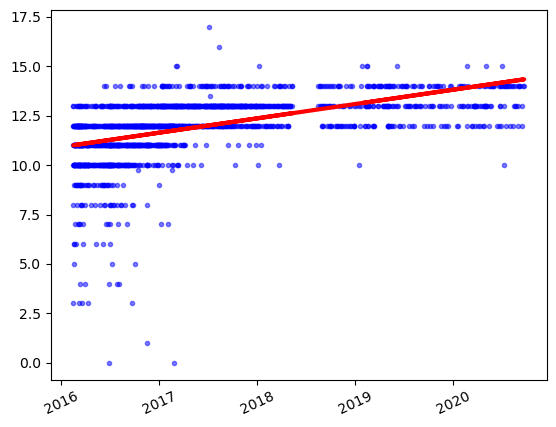

In [12]:
plt.xticks(rotation=25)
plt.plot(dog_rating_df['created_at'], dog_rating_df['int_ratings'], 'b.', alpha=0.5)
plt.plot(dog_rating_df['created_at'], dog_rating_df['timestamp']*best_fit_line.slope + best_fit_line.intercept, 'r-', linewidth=3)
plt.show()